In [1]:
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt

from utils.score_responses import ResponseEvaluator
from utils.parsing import parse_fen
from utils.board import get_piece_name_at_location

In [2]:
PARENT_DIR = Path("model_outputs")
DATA_FOLDERS = [
    "llmchess-qwen25-7b-sft-dm22-400",
    "llmchess-qwen25-7b-sft-dm23-400",
    "llmchess-qwen25-7b-sft-dm24-400",
    "llmchess-qwen25-7b-sft-dm25-400",
    "llmchess-qwen25-7b-sft-dm26-400",
    "llmchess-qwen25-7b-sft-dm27-400",
    "eval-qwen25-7b-sftdm22-drgrpo-dm11-400",
    "eval-qwen25-7b-sftdm23-drgrpo-dm10-400",
    "eval-qwen25-7b-sftdm24-drgrpo-dm10-400",
    "eval-qwen25-7b-sftdm25-drgrpo-dm10-400",
    "eval-qwen25-7b-sftdm26-drgrpo-dm10-400",
    "eval-qwen25-7b-sftdm27-drgrpo-dm10-400"
]

In [3]:
# Populate our board result dicts
board_result_dicts = {}
for data_folder in DATA_FOLDERS:
    folder_path = Path(PARENT_DIR) if data_folder is None else Path(PARENT_DIR) / data_folder
    for json_file in folder_path.glob("*.json*"):
        if json_file.suffix not in {".json", ".jsonl"}:
            continue
        key = f"{json_file.name} - [{data_folder}]"
        evaluator = ResponseEvaluator(str(folder_path), json_file.name)
        board_result_dicts[key] = evaluator.board_id_results

--------------------------------------------------
Results for predictmove_eval_400_all_20250808-221920.json:
Filename: predictmove_eval_400_all_20250808-221920.json
Count: Sample Questions: 400
Count: Total Generations: 400
Count: Legal Generations: 135
Total: Cumulative Score: 80.09253397653748
Error: Illegal Move: 265
Error: Parsing: 0
Error: Other: 0
Avg. Score - All: 0.2002313349413437
Avg. Score - Legal: 0.5932780294558332
Error Rate: 0.6625
--------------------------------------------------

--------------------------------------------------
Results for predictmove_eval_400_all_20250808-221823.json:
Filename: predictmove_eval_400_all_20250808-221823.json
Count: Sample Questions: 400
Count: Total Generations: 400
Count: Legal Generations: 147
Total: Cumulative Score: 84.2238628188891
Error: Illegal Move: 253
Error: Parsing: 0
Error: Other: 0
Avg. Score - All: 0.21055965704722276
Avg. Score - Legal: 0.5729514477475449
Error Rate: 0.6325
--------------------------------------------

In [4]:
def bar_by(df, x_col, y_col, *, n_bins=10, title=None):
    """
    Dual‑axis bar plot:
      • left  y‑axis: mean(y_col) per bucket (blue)
      • right y‑axis: count per bucket (orange)

    Buckets: unique values if ≤10 else `n_bins` equal‑width numeric buckets.
    """
    x, y = df[x_col], df[y_col]

    # ── Bucket assignment ────────────────────────────────────────────
    if pd.api.types.is_numeric_dtype(x):
        if x.nunique() <= 10:
            labels = sorted(x.unique())
            grp_idx = x
        else:
            bins   = np.linspace(x.min(), x.max(), n_bins + 1)
            labels = [f"{int(bins[i])}–{int(bins[i+1]-1)}" for i in range(n_bins)]
            grp_idx = pd.cut(x, bins=bins, labels=labels, include_lowest=True)
    else:  # categorical x
        labels  = sorted(x.astype(str).unique())
        grp_idx = x.astype(str)

    # ── Aggregation ──────────────────────────────────────────────────
    mean_vals  = y.groupby(grp_idx, observed=True).mean().reindex(labels)
    count_vals = y.groupby(grp_idx, observed=True).count().reindex(labels).fillna(0)

    # ── Plot ─────────────────────────────────────────────────────────
    xpos, width = np.arange(len(labels)), 0.35
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    bars_mean  = ax1.bar(xpos - width/2, mean_vals.values, width, color="#1f77b4")
    bars_count = ax2.bar(xpos + width/2, count_vals.values, width,
                         color="orange", label="# samples")

    ax1.set_xlabel(x_col)
    ax1.set_ylabel(f"mean({y_col})")
    ax2.set_ylabel("count")
    ax1.set_xticks(xpos)
    ax1.set_xticklabels(labels, rotation=45, ha="right")
    ax1.set_title(title or f"{y_col} by {x_col}")

    # Annotate bars
    for rect in bars_mean:
        ax1.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{rect.get_height():.2f}",
                 ha="center", va="bottom", fontsize=8)
    for rect in bars_count:
        ax2.text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 0.01,
                 f"{int(rect.get_height())}",
                 ha="center", va="bottom", fontsize=8)

    ax1.legend([bars_count], ["# samples"], loc="upper right")
    fig.tight_layout()
    plt.show()

# Predict Move   
---

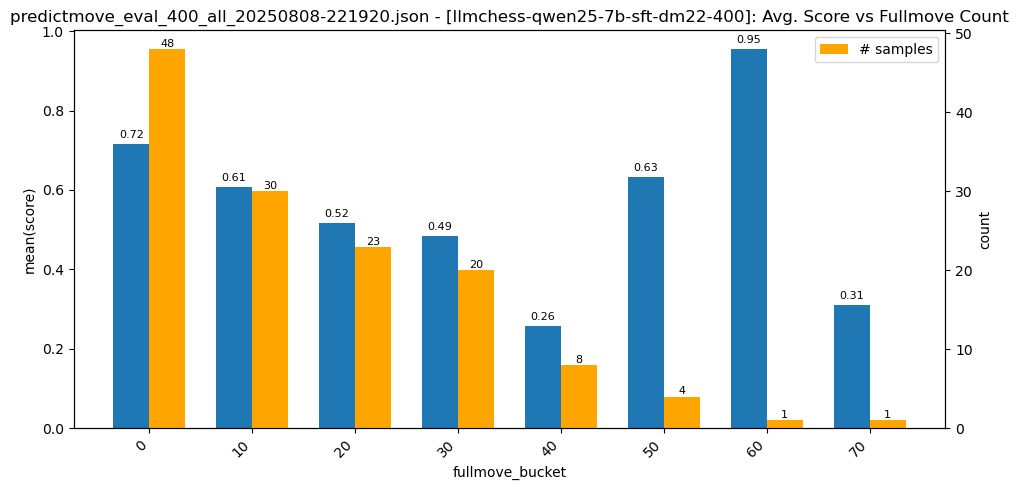


predictmove_eval_400_all_20250808-221920.json - [llmchess-qwen25-7b-sft-dm22-400] — Top 20 moves:
b8c6     count=36    mean=0.710 std=0.266
b1c3     count=19    mean=0.654 std=0.281
d7d5     count=17    mean=0.740 std=0.214
e1g1     count=16    mean=0.904 std=0.081
g8f6     count=13    mean=0.707 std=0.334
e8g8     count=12    mean=0.724 std=0.257
f7f5     count=9     mean=0.771 std=—
g1f3     count=7     mean=0.838 std=0.092
b7b5     count=7     mean=0.483 std=—
d1d3     count=6     mean=0.523 std=0.445
c7c5     count=5     mean=0.875 std=—
c8a6     count=5     mean=— std=—
d1c2     count=4     mean=0.731 std=—
c2c4     count=4     mean=— std=—
f2f4     count=4     mean=0.667 std=—
e2e4     count=3     mean=0.161 std=—
g1h1     count=3     mean=0.687 std=0.103
d1e2     count=3     mean=0.721 std=0.014
c8b7     count=3     mean=— std=—
d2d4     count=3     mean=0.929 std=—
------------------------------------------------------------


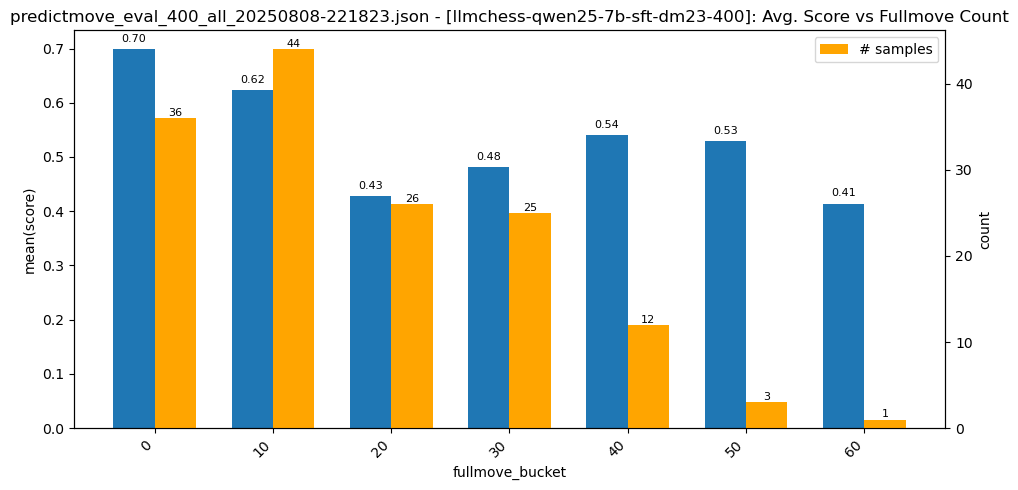


predictmove_eval_400_all_20250808-221823.json - [llmchess-qwen25-7b-sft-dm23-400] — Top 20 moves:
b8c6     count=30    mean=0.799 std=0.157
b1c3     count=22    mean=0.712 std=0.233
c7c5     count=18    mean=0.625 std=0.223
d7d5     count=15    mean=0.785 std=0.217
e1g1     count=15    mean=0.857 std=0.154
g8f6     count=14    mean=0.774 std=0.114
e8g8     count=11    mean=0.840 std=0.165
f7f5     count=7     mean=0.580 std=0.308
d1d3     count=7     mean=0.362 std=0.190
b2b3     count=7     mean=0.400 std=0.123
c8a6     count=6     mean=0.548 std=—
d8d7     count=4     mean=0.083 std=—
d1h5     count=4     mean=— std=—
d1e2     count=4     mean=0.714 std=0.051
d2d4     count=4     mean=0.862 std=0.137
b7b5     count=3     mean=— std=—
f2f3     count=3     mean=0.423 std=0.078
b2c3     count=3     mean=0.545 std=—
g1f3     count=3     mean=0.951 std=—
f3g5     count=3     mean=0.558 std=0.253
------------------------------------------------------------


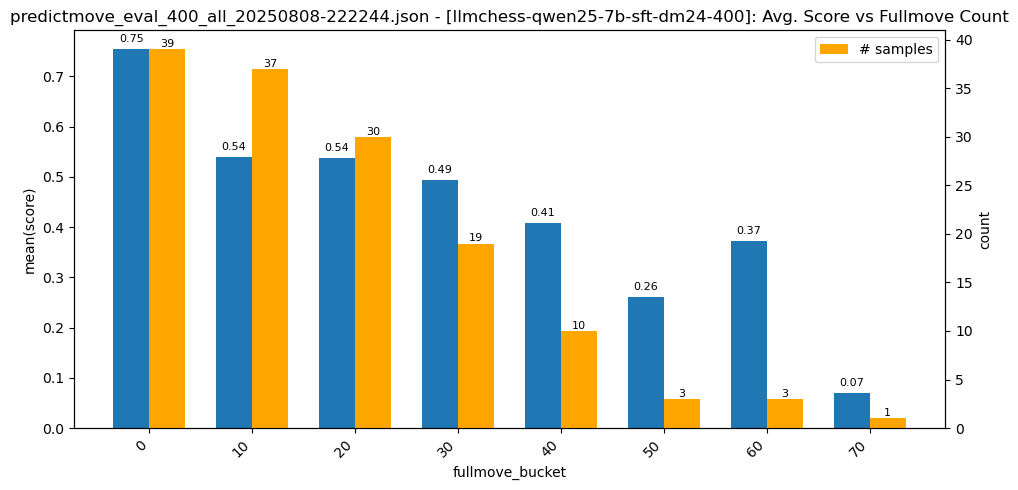


predictmove_eval_400_all_20250808-222244.json - [llmchess-qwen25-7b-sft-dm24-400] — Top 20 moves:
b8c6     count=24    mean=0.753 std=0.253
g8f6     count=23    mean=0.814 std=0.110
d7d5     count=20    mean=0.474 std=0.320
b1c3     count=14    mean=0.764 std=0.197
c7c5     count=14    mean=0.573 std=0.239
e1g1     count=9     mean=0.908 std=0.062
d2d4     count=7     mean=— std=—
g1f3     count=7     mean=0.797 std=0.095
c2c4     count=6     mean=0.857 std=—
c1d1     count=5     mean=0.473 std=0.144
e2e4     count=5     mean=0.026 std=—
d1d3     count=5     mean=0.750 std=—
f7f5     count=5     mean=0.000 std=—
e8g8     count=5     mean=0.694 std=—
b7b5     count=5     mean=0.726 std=0.105
g1h1     count=5     mean=0.511 std=0.113
f1d1     count=5     mean=0.913 std=—
c6c5     count=4     mean=0.974 std=—
d1e2     count=4     mean=0.555 std=0.132
c2d3     count=3     mean=0.159 std=—
------------------------------------------------------------


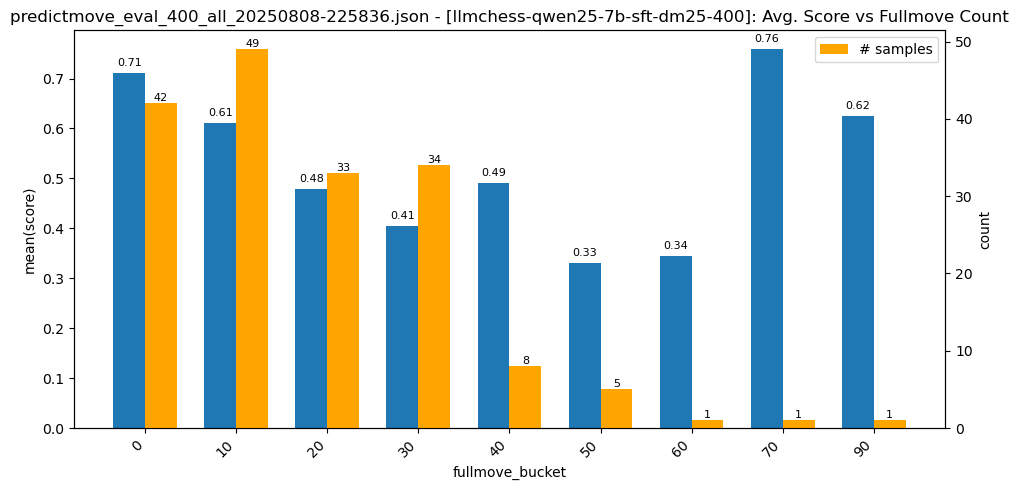


predictmove_eval_400_all_20250808-225836.json - [llmchess-qwen25-7b-sft-dm25-400] — Top 20 moves:
b8c6     count=28    mean=0.729 std=0.226
d7d5     count=21    mean=0.509 std=0.404
b1c3     count=21    mean=0.713 std=0.184
g8f6     count=18    mean=0.803 std=0.103
c7c5     count=12    mean=0.414 std=0.186
e1g1     count=11    mean=0.845 std=0.103
g1f3     count=10    mean=0.679 std=—
b7b5     count=10    mean=0.707 std=0.235
e8g8     count=9     mean=0.855 std=0.145
d1d3     count=8     mean=0.595 std=0.248
f7f5     count=7     mean=0.062 std=0.088
d8d7     count=7     mean=0.234 std=0.233
c2c4     count=6     mean=— std=—
d1e2     count=6     mean=0.650 std=0.110
e2e4     count=5     mean=0.431 std=0.381
d8d5     count=5     mean=0.438 std=0.581
d2d4     count=4     mean=0.190 std=—
e7e5     count=4     mean=— std=—
c1b1     count=3     mean=0.656 std=0.057
g7g5     count=3     mean=0.647 std=0.089
------------------------------------------------------------


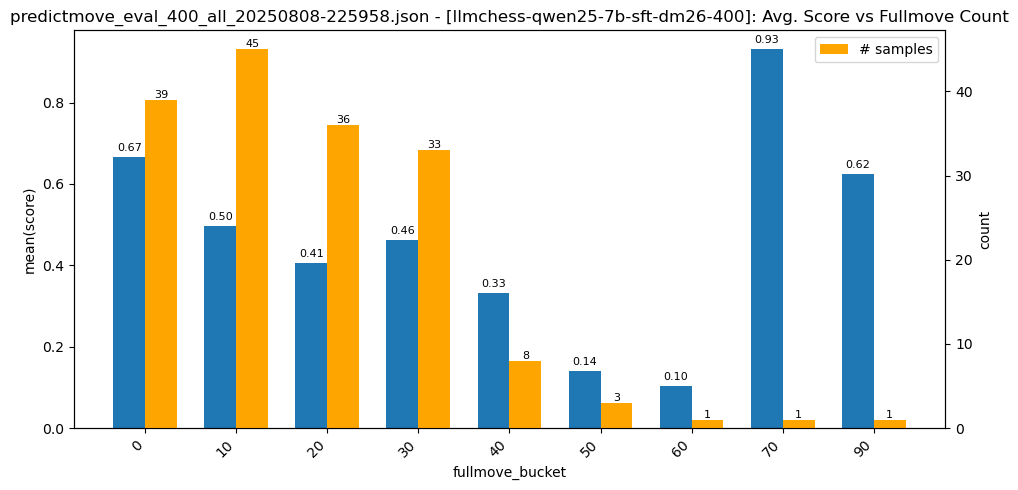


predictmove_eval_400_all_20250808-225958.json - [llmchess-qwen25-7b-sft-dm26-400] — Top 20 moves:
d7d5     count=28    mean=0.638 std=0.305
b8c6     count=25    mean=0.689 std=0.249
b1c3     count=21    mean=0.679 std=0.261
c7c5     count=15    mean=0.438 std=0.144
g8f6     count=9     mean=0.656 std=0.469
g1f3     count=9     mean=— std=—
e1g1     count=7     mean=0.726 std=0.214
d2d4     count=7     mean=0.000 std=—
b7b5     count=6     mean=0.538 std=0.252
e8g8     count=5     mean=0.801 std=0.297
c2b2     count=4     mean=0.640 std=—
c8g4     count=4     mean=— std=—
e7e5     count=4     mean=— std=—
f7f5     count=4     mean=0.097 std=0.137
g1h1     count=4     mean=0.549 std=0.247
c6b4     count=3     mean=0.500 std=—
a2a4     count=3     mean=0.530 std=0.405
a8a5     count=3     mean=— std=—
d3e4     count=3     mean=0.024 std=—
f3g5     count=3     mean=0.128 std=0.064
------------------------------------------------------------


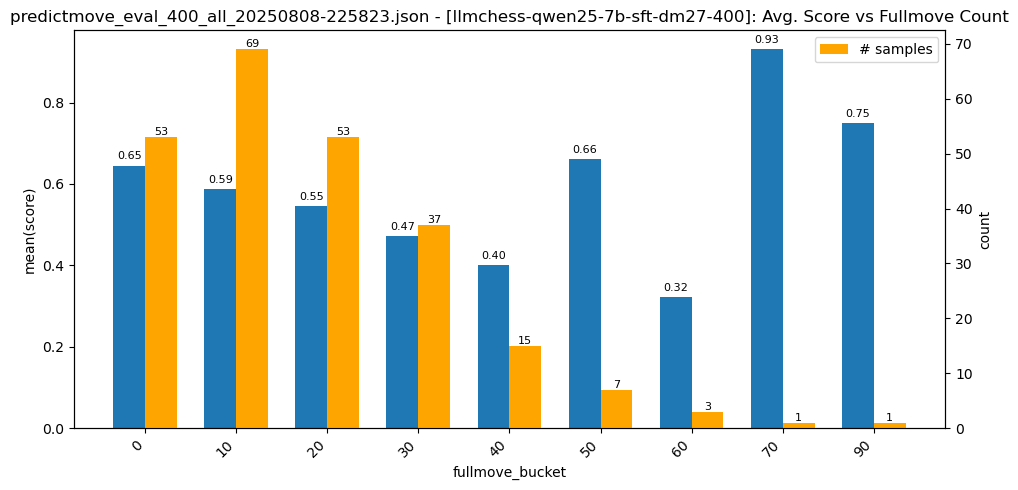


predictmove_eval_400_all_20250808-225823.json - [llmchess-qwen25-7b-sft-dm27-400] — Top 20 moves:
b8c6     count=15    mean=0.704 std=0.281
g8f6     count=12    mean=0.642 std=0.379
b1c3     count=11    mean=0.662 std=0.279
d7d5     count=10    mean=0.702 std=0.341
e1g1     count=9     mean=0.840 std=0.115
e8g8     count=8     mean=0.931 std=0.074
g1f3     count=7     mean=0.812 std=0.048
f3g5     count=6     mean=0.483 std=0.380
c8b7     count=5     mean=— std=—
e7e5     count=5     mean=0.554 std=0.526
f7f5     count=4     mean=0.000 std=—
c7c5     count=4     mean=0.456 std=0.186
d1d2     count=4     mean=0.371 std=0.186
c2c4     count=4     mean=0.457 std=—
d2d4     count=3     mean=0.708 std=0.354
g8h6     count=3     mean=0.417 std=—
d1d3     count=3     mean=0.073 std=—
c8b6     count=3     mean=— std=—
d7d6     count=3     mean=0.402 std=0.369
c3b5     count=3     mean=0.578 std=0.433
------------------------------------------------------------


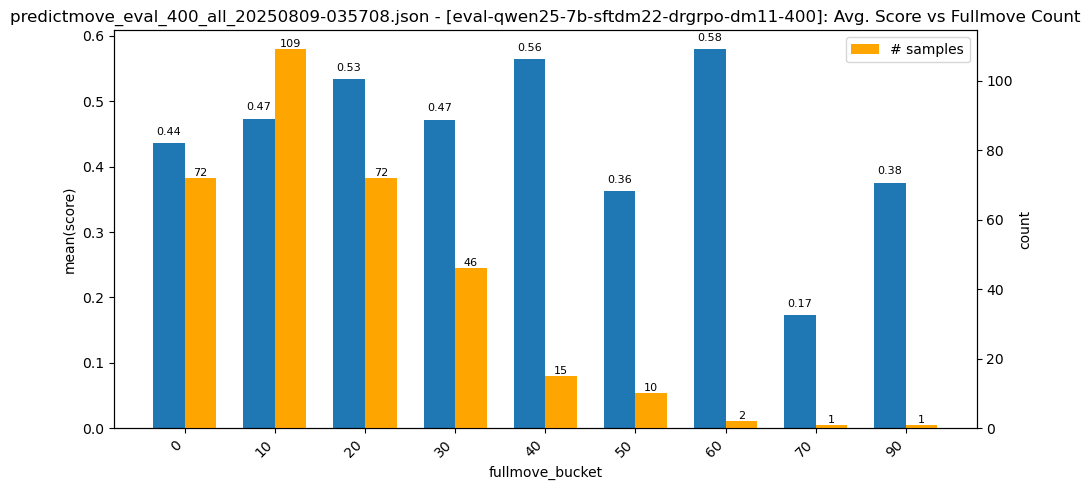


predictmove_eval_400_all_20250809-035708.json - [eval-qwen25-7b-sftdm22-drgrpo-dm11-400] — Top 20 moves:
g1h1     count=83    mean=0.503 std=0.237
g8h8     count=55    mean=0.457 std=0.243
h1g1     count=27    mean=0.437 std=0.224
h8g8     count=26    mean=0.431 std=0.221
e8d8     count=21    mean=0.344 std=0.209
e1d1     count=19    mean=0.467 std=0.188
a8b8     count=11    mean=0.485 std=0.136
c8b8     count=11    mean=0.613 std=0.289
d8e7     count=9     mean=0.485 std=0.307
c1b1     count=9     mean=0.432 std=0.217
b8c6     count=7     mean=0.635 std=0.194
g7h8     count=6     mean=0.488 std=0.211
g2h1     count=6     mean=0.492 std=0.213
b8a8     count=5     mean=0.508 std=0.312
h7g8     count=5     mean=0.579 std=0.313
d1e2     count=5     mean=0.552 std=0.216
d1c1     count=5     mean=0.138 std=0.007
f1e1     count=4     mean=0.714 std=0.268
g6h7     count=3     mean=0.414 std=0.460
b2a1     count=3     mean=0.359 std=0.336
------------------------------------------------------

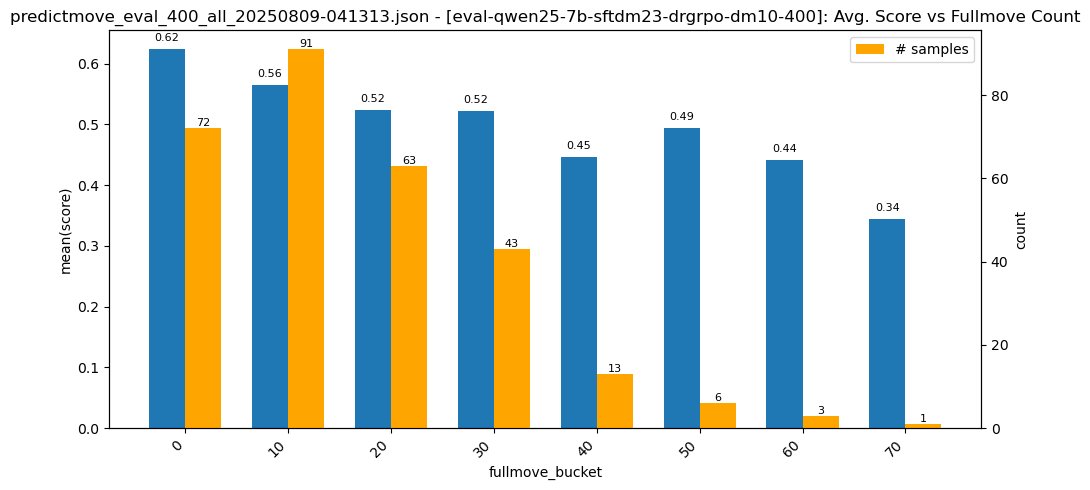


predictmove_eval_400_all_20250809-041313.json - [eval-qwen25-7b-sftdm23-drgrpo-dm10-400] — Top 20 moves:
a1b1     count=82    mean=0.551 std=0.185
a8b8     count=71    mean=0.570 std=0.206
b8c6     count=43    mean=0.681 std=0.250
b1c3     count=22    mean=0.733 std=0.161
d1e1     count=11    mean=0.554 std=0.304
b8c8     count=11    mean=0.566 std=0.269
c1b1     count=9     mean=0.362 std=0.263
b1c1     count=9     mean=0.464 std=0.319
d8c8     count=8     mean=0.701 std=0.112
c8b8     count=7     mean=0.500 std=0.403
f1e1     count=6     mean=0.457 std=0.464
f8e8     count=6     mean=0.594 std=0.242
d8e8     count=5     mean=0.461 std=0.254
b2c2     count=4     mean=0.734 std=0.159
g8h8     count=4     mean=0.383 std=0.306
c2b2     count=4     mean=0.677 std=0.053
g1f1     count=4     mean=0.729 std=0.206
c4b4     count=4     mean=0.517 std=0.153
e8f8     count=4     mean=0.590 std=0.036
d1c1     count=3     mean=0.260 std=0.014
------------------------------------------------------

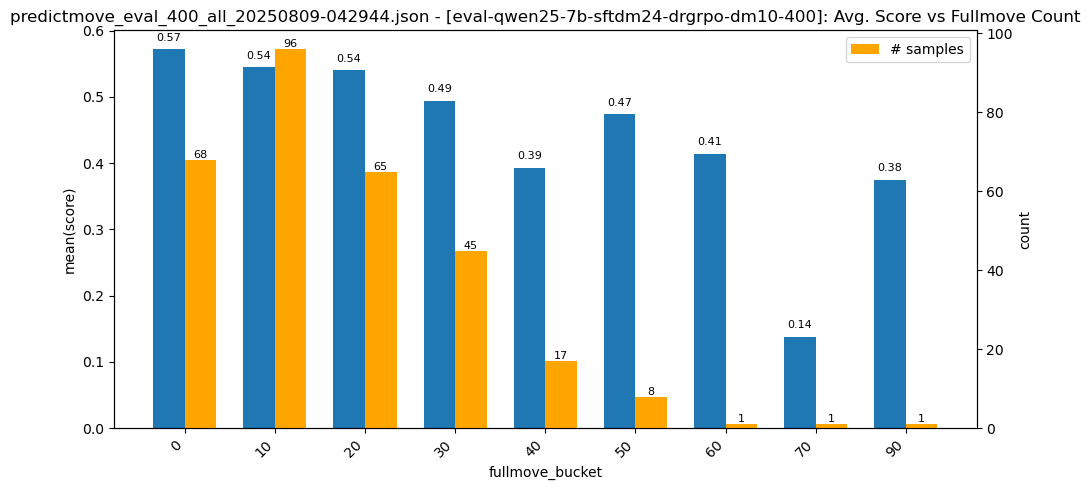


predictmove_eval_400_all_20250809-042944.json - [eval-qwen25-7b-sftdm24-drgrpo-dm10-400] — Top 20 moves:
a8b8     count=75    mean=0.574 std=0.215
a1b1     count=58    mean=0.521 std=0.187
b8c6     count=25    mean=0.663 std=0.289
b1c3     count=21    mean=0.657 std=0.210
g1h1     count=21    mean=0.435 std=0.275
c1b1     count=17    mean=0.468 std=0.243
c8b8     count=15    mean=0.664 std=0.256
b8a8     count=10    mean=0.559 std=0.307
e1d1     count=10    mean=0.547 std=0.351
e8d8     count=9     mean=0.524 std=0.378
d8c8     count=7     mean=0.477 std=0.261
f1e1     count=6     mean=0.412 std=0.361
b8c8     count=6     mean=0.423 std=0.172
d8e8     count=5     mean=0.469 std=0.233
f8e8     count=5     mean=0.540 std=0.212
b7b5     count=4     mean=0.438 std=0.062
b1c1     count=4     mean=0.307 std=0.375
d1e2     count=4     mean=0.717 std=0.015
d1c1     count=4     mean=0.264 std=0.157
b3c1     count=3     mean=— std=—
------------------------------------------------------------


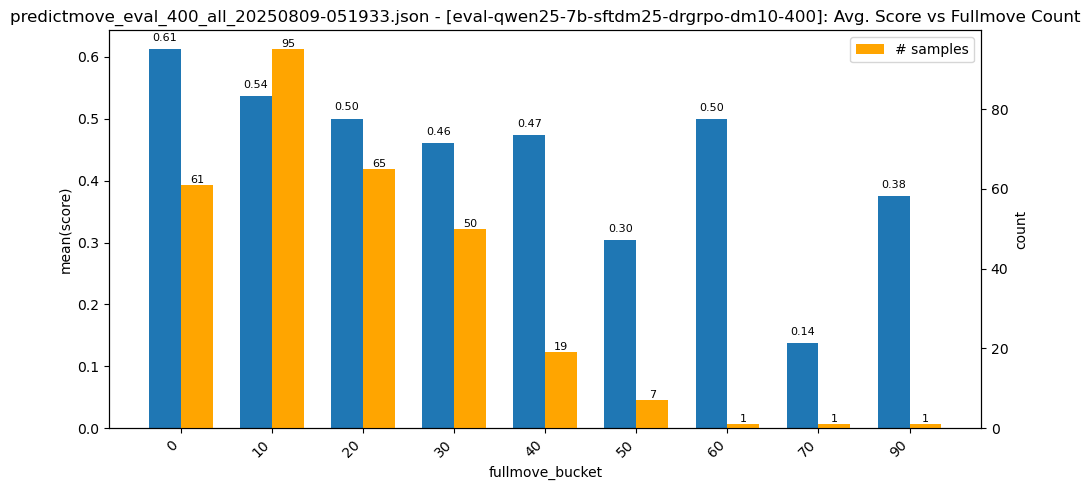


predictmove_eval_400_all_20250809-051933.json - [eval-qwen25-7b-sftdm25-drgrpo-dm10-400] — Top 20 moves:
a1b1     count=29    mean=0.596 std=0.203
g1h1     count=26    mean=0.477 std=0.256
g8h8     count=25    mean=0.443 std=0.276
b7b6     count=17    mean=0.565 std=0.202
e8g8     count=17    mean=0.878 std=0.128
f1e1     count=15    mean=0.522 std=0.334
b1c3     count=15    mean=0.716 std=0.238
a8b8     count=13    mean=0.547 std=0.255
c1b1     count=11    mean=0.392 std=0.189
c8b8     count=10    mean=0.580 std=0.286
g8f6     count=10    mean=0.728 std=0.208
b8c6     count=10    mean=0.615 std=0.323
e1g1     count=9     mean=0.812 std=0.169
d8d7     count=9     mean=0.451 std=0.347
e1d1     count=8     mean=0.436 std=0.292
b8c8     count=7     mean=0.485 std=0.331
b2b3     count=7     mean=0.509 std=0.318
h8g8     count=6     mean=0.571 std=0.469
g2g3     count=6     mean=0.359 std=0.096
e1e2     count=5     mean=0.508 std=0.372
------------------------------------------------------

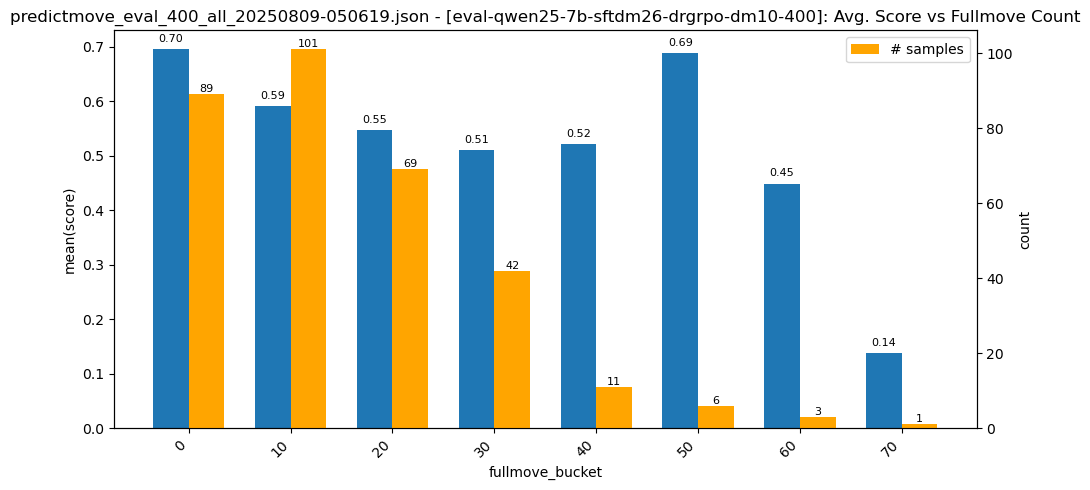


predictmove_eval_400_all_20250809-050619.json - [eval-qwen25-7b-sftdm26-drgrpo-dm10-400] — Top 20 moves:
a7a6     count=99    mean=0.662 std=0.205
a2a4     count=88    mean=0.654 std=0.200
a6a5     count=25    mean=0.516 std=0.250
a3a4     count=22    mean=0.395 std=0.203
a7a5     count=20    mean=0.558 std=0.310
a2a3     count=13    mean=0.643 std=0.185
a4a5     count=12    mean=0.697 std=0.248
b2b3     count=7     mean=0.485 std=0.244
a8a5     count=6     mean=0.653 std=0.217
c7c6     count=5     mean=0.445 std=0.232
c2c3     count=4     mean=0.523 std=0.259
a1a2     count=3     mean=0.614 std=0.354
a1a3     count=3     mean=0.669 std=0.024
a4a3     count=3     mean=0.395 std=0.371
b7c8     count=3     mean=0.781 std=—
c1b1     count=2     mean=0.288 std=0.064
a5a6     count=2     mean=0.938 std=0.041
b5c4     count=2     mean=0.333 std=—
b7b5     count=2     mean=0.558 std=0.129
a7c6     count=2     mean=0.533 std=0.632
------------------------------------------------------------


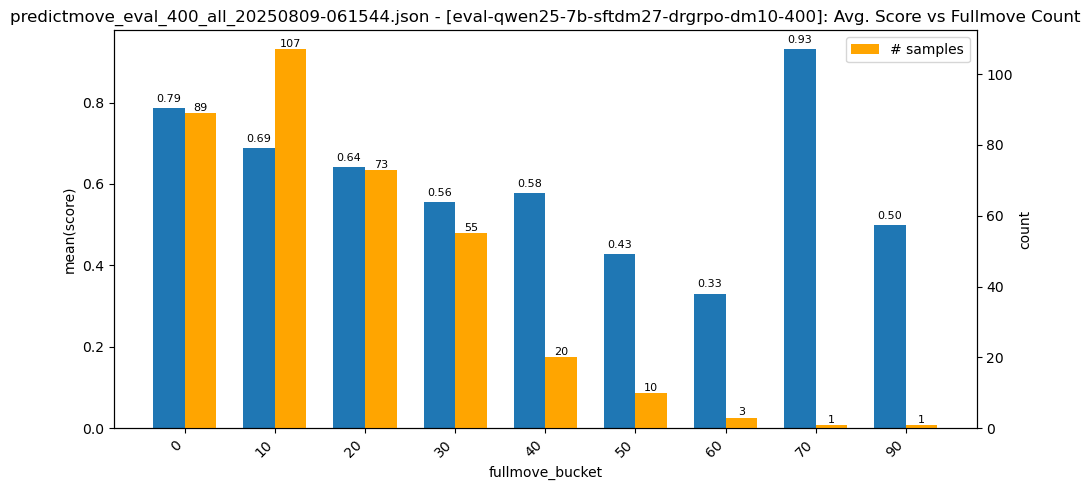


predictmove_eval_400_all_20250809-061544.json - [eval-qwen25-7b-sftdm27-drgrpo-dm10-400] — Top 20 moves:
g8f6     count=16    mean=0.749 std=0.216
h2h3     count=13    mean=0.705 std=0.223
a2a4     count=10    mean=0.675 std=0.260
h3h4     count=10    mean=0.651 std=0.213
g2g3     count=9     mean=0.657 std=0.235
h7h6     count=7     mean=0.655 std=0.338
a7a5     count=7     mean=0.610 std=0.336
g1f3     count=6     mean=0.910 std=0.064
f8e7     count=6     mean=0.830 std=0.116
g7g6     count=6     mean=0.814 std=0.145
g2g4     count=6     mean=0.566 std=0.352
c7c6     count=6     mean=0.714 std=0.328
d7d5     count=6     mean=0.707 std=0.183
h6h5     count=5     mean=0.729 std=0.192
<ERROR>  count=5     mean=— std=—
h7h5     count=4     mean=0.737 std=0.137
a8d8     count=4     mean=0.736 std=0.146
f7f5     count=3     mean=0.443 std=0.460
g4f5     count=3     mean=0.653 std=0.263
e4e5     count=3     mean=0.651 std=0.407
------------------------------------------------------------


In [5]:
for key, results in board_result_dicts.items():
    if not key.startswith("predictmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fullmove = parse_fen(data['info']["board"])["fullmove_number"]
        for score_raw, move in data.get("score_answers", []):
            try:         # numeric score or NaN for '<ERROR>'
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "move":     move,
                "score":    score,
            })

    if not rows:
        continue

    df = pd.DataFrame(rows)

    # ── 1) Histogram (mean score vs fullmove buckets) ────────────
    clean_df = df.dropna(subset=["score"])
    if not clean_df.empty:
        df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
        bar_by(
            df.dropna(subset=["score"]),
            x_col="fullmove_bucket",
            y_col="score",
            title=f"{key}: Avg. Score vs Fullmove Count"
        )

    # ── 2) Move statistics ───────────────────────────────────────
    print(f"\n{key} — Top 20 moves:")
    move_counts = df["move"].value_counts().head(20)
    move_stats  = (
        df.groupby("move")["score"]
            .agg(["mean", "std"])
            .reindex(move_counts.index)
    )
    for mv in move_counts.index:
        cnt  = move_counts[mv]
        mean = move_stats.loc[mv, "mean"]
        std  = move_stats.loc[mv, "std"]
        mean_str = f"{mean:.3f}" if not np.isnan(mean) else "—"
        std_str  = f"{std:.3f}"  if not np.isnan(std)  else "—"
        print(f"{mv:<8} count={cnt:<5} mean={mean_str} std={std_str}")
    print("-" * 60)

# Legal Moves   
---

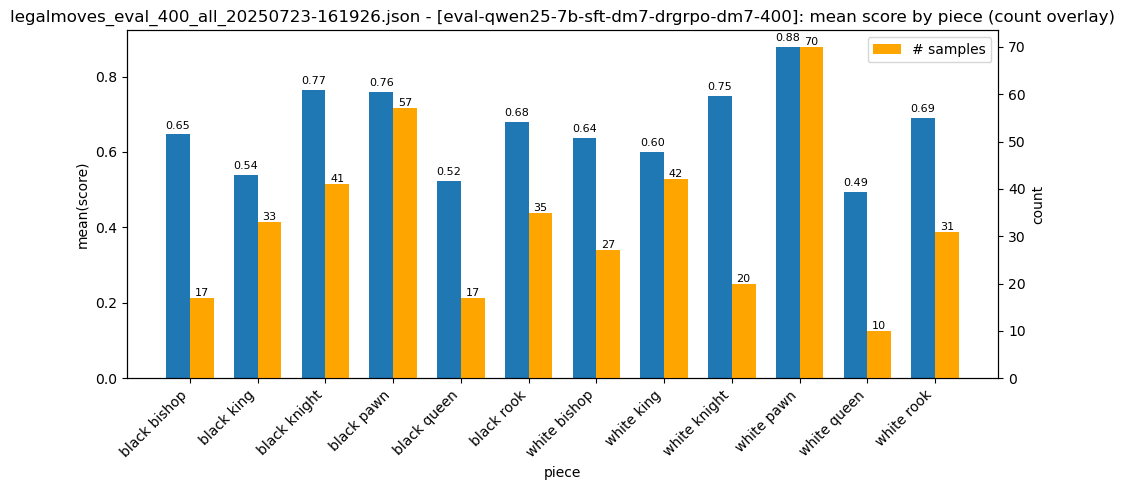

In [6]:
for key, results in board_result_dicts.items():
    if not key.startswith("legalmoves"):
        continue

    rows = []
    for board_id, data in results.items():
        piece = data["info"]["task_data"][0]   # e.g. 'black bishop'
        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)      # 0‥1 numeric
            except (ValueError, TypeError):
                score = pd.NA                 # '<ERROR>' → NA
            rows.append({"piece": piece, "score": score})

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores")
        continue

    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )

# Best Move   
---

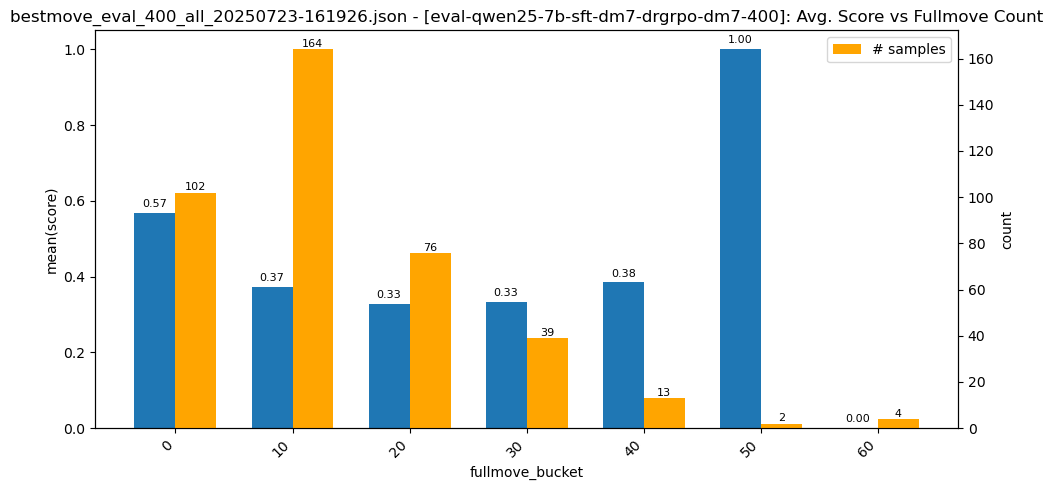

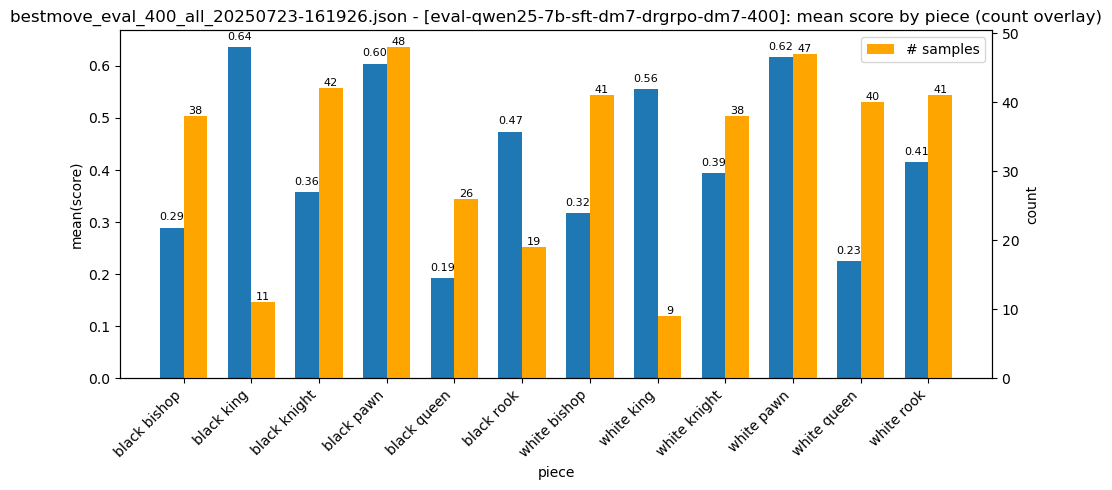

In [7]:
for key, results in board_result_dicts.items():
    if not key.startswith("bestmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fen       = data["info"]["board"]
        fullmove  = parse_fen(fen)["fullmove_number"]
        # correct answer square = first 2 chars of SAN‑less move string
        src_sq    = data["info"]["answer"]["answer"][:2].lower()

        piece = get_piece_name_at_location(fen, src_sq)  # e.g. 'white knight'

        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "piece":    piece,
                "score":    score,
            })

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores.")
        continue

    # ─── 1) Score vs full‑move count buckets ────────────────────
    df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
    bar_by(
        df.dropna(subset=["score"]),
        x_col="fullmove_bucket",
        y_col="score",
        title=f"{key}: Avg. Score vs Fullmove Count"
    )

    # ─── 2) Score vs piece type ─────────────────────────────────
    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )

# Worst Move   
---

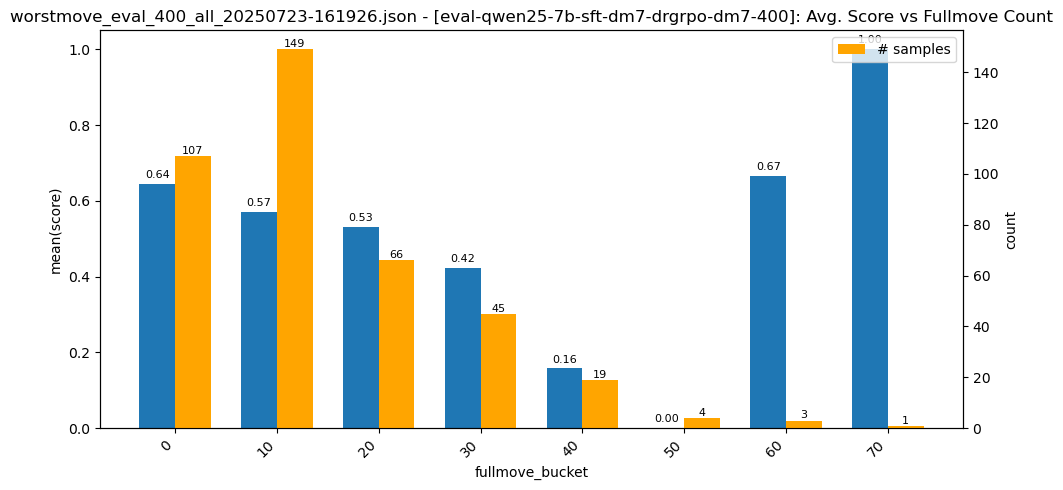

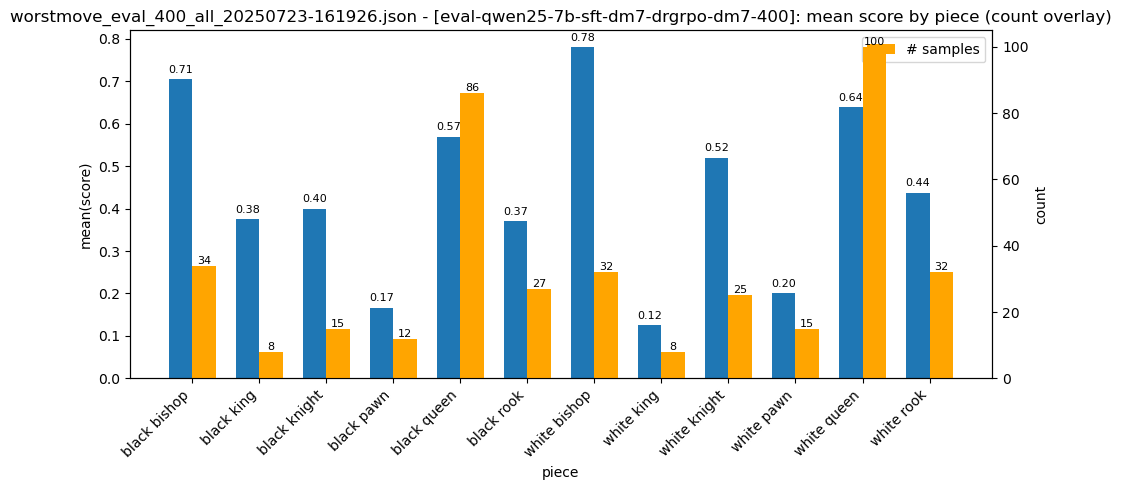

In [8]:
for key, results in board_result_dicts.items():
    if not key.startswith("worstmove"):
        continue

    rows = []
    for board_id, data in results.items():
        fen       = data["info"]["board"]
        fullmove  = parse_fen(fen)["fullmove_number"]
        # correct answer square = first 2 chars of SAN‑less move string
        src_sq    = data["info"]["answer"]["answer"][:2].lower()

        piece = get_piece_name_at_location(fen, src_sq)  # e.g. 'white knight'

        for score_raw, _ in data.get("score_answers", []):
            try:
                score = float(score_raw)
            except (ValueError, TypeError):
                score = np.nan
            rows.append({
                "board_id": board_id,
                "fullmove": fullmove,
                "piece":    piece,
                "score":    score,
            })

    df = pd.DataFrame(rows).dropna(subset=["score"]).astype({"score": float})
    if df.empty:
        print(f"{key}: no valid scores.")
        continue

    # ─── 1) Score vs full‑move count buckets ────────────────────
    df["fullmove_bucket"] = (df["fullmove"] // 10) * 10
    bar_by(
        df.dropna(subset=["score"]),
        x_col="fullmove_bucket",
        y_col="score",
        title=f"{key}: Avg. Score vs Fullmove Count"
    )

    # ─── 2) Score vs piece type ─────────────────────────────────
    bar_by(
        df,
        x_col="piece",
        y_col="score",
        title=f"{key}: mean score by piece (count overlay)"
    )